# Klasifikasi Berita Clickbait Menggunakan Mamba Selective State Space Model

## Instalasi Library

In [ ]:
# Instalasi Library Dasar dan Dependensi Mamba
!pip install -q transformers pandas scikit-learn matplotlib seaborn
!pip install -q newspaper3k lxml_html_clean
!pip install -q ninja packaging
!pip install -q --no-build-isolation causal-conv1d>=1.2.0
!pip install -q --no-build-isolation mamba-ssm

print("Instalasi selesai.")


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 47.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.1/211.1 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 15.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 17.4 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.8/260.8 kB 19.0 MB/s eta 0

## Dataset & Tokenizer IndoBERTweet

In [ ]:
# Menghubungkan Google Drive, Dataset, dan Tokenizer
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from sklearn.model_selection import KFold
from transformers import AutoTokenizer
from google.colab import drive

# Menghubungkan ke Google Drive
drive.mount('/content/drive')

# Setup Perangkat Komputasi
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# Load Tokenizer IndoBERTweet
tokenizer = AutoTokenizer.from_pretrained("indolem/indobertweet-base-uncased")
print("Tokenizer berhasil dimuat")


class ClickbaitDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = float(self.labels[idx])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label':          torch.tensor(label, dtype=torch.float)
        }


# Membaca Data dari Google Drive
file_path = '/content/drive/MyDrive/Skripsi/dataset_final.csv'

df     = pd.read_csv(file_path)
df     = df.dropna(subset=['text_input', 'label'])
texts  = df['text_input'].values
labels = df['label'].values

# Membuat objek dataset utuh untuk K-Fold
full_dataset = ClickbaitDataset(texts, labels, tokenizer)
print(f" [SISTEM] Total dataset siap diproses: {len(full_dataset)} baris.")


Mounted at /content/drive
Menggunakan device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer berhasil dimuat
 [SISTEM] Total dataset siap diproses: 14701 baris.


## Arsitektur MambaClickbaitClassifier

In [ ]:
# ARSITEKTUR MAMBA SSM
import torch.nn as nn
from mamba_ssm import Mamba


class MambaClickbaitClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=256, d_state=16, d_conv=4, expand=2):
        super(MambaClickbaitClassifier, self).__init__()

        # Lapisan 1 — Embedding: konversi token ID → vektor padat berdimensi d_model
        self.embedding = nn.Embedding(vocab_size, d_model)

        # Lapisan 2 — Mamba SSM: pemodelan sekuensial dengan kompleksitas linier O(n)
        # Parameter: d_model=256 (dimensi), d_state=16 (dimensi ruang keadaan),
        #            d_conv=4 (kernel konvolusi 1D), expand=2 (faktor ekspansi internal)
        self.mamba = Mamba(d_model=d_model, d_state=d_state, d_conv=d_conv, expand=expand)

        # Lapisan 3 — Layer Normalization: menstabilkan distribusi fitur sebelum klasifikasi
        self.norm = nn.LayerNorm(d_model)

        # Lapisan 4 — Adaptive Average Pooling: mereduksi representasi dokumen
        self.pool = nn.AdaptiveAvgPool1d(1)

        # Lapisan 5 — Fully Connected + Sigmoid: menghasilkan probabilitas biner [0, 1]
        self.fc      = nn.Linear(d_model, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_ids):
        x      = self.embedding(input_ids)   # (B, L) → (B, L, d_model)
        x      = self.mamba(x)               # (B, L, d_model) → (B, L, d_model)
        x      = self.norm(x)                # Normalisasi lapisan per sampel
        x      = x.transpose(1, 2)           # (B, L, d) → (B, d, L) untuk pooling
        x      = self.pool(x).squeeze(-1)    # (B, d, L) → (B, d)
        logits = self.fc(x)                  # (B, d) → (B, 1)
        probs  = self.sigmoid(logits).squeeze(-1)  # (B,) ∈ [0, 1]
        return probs


# Inisialisasi model ke GPU/CPU
vocab_size = tokenizer.vocab_size
model      = MambaClickbaitClassifier(vocab_size=vocab_size).to(device)

# Menampilkan detail arsitektur untuk log sidang
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(" [SISTEM] ARSITEKTUR MAMBA BERHASIL DIBANGUN")
print(f" Kapasitas Kosakata (Vocab)  : {vocab_size} token")
print(f" Dimensi Vektor (d_model)    : 256")
print(f" Kapasitas Memori (d_state)  : 16")
print(f" Kernel Konvolusi 1D (d_conv): 4")
print(f" Faktor Ekspansi (expand)    : 2")
print(f" Total Parameter Latih       : {total_params:,} parameter")
print()
print(" Alur Forward Pass:")
print("   Input IDs -> Embedding(256) -> Mamba SSM -> LayerNorm -> AvgPool -> FC(1) -> Sigmoid -> Probabilitas")


 [SISTEM] ARSITEKTUR MAMBA BERHASIL DIBANGUN
 Kapasitas Kosakata (Vocab)  : 31923 token
 Dimensi Vektor (d_model)    : 256
 Kapasitas Memori (d_state)  : 16
 Kernel Konvolusi 1D (d_conv): 4
 Faktor Ekspansi (expand)    : 2
 Total Parameter Latih       : 8,610,817 parameter

 Alur Forward Pass:
   Input IDs -> Embedding(256) -> Mamba SSM -> LayerNorm -> AvgPool -> FC(1) -> Sigmoid -> Probabilitas


## Pelatihan K-Fold Cross Validation (k=3)

 MEMULAI K-FOLD CROSS VALIDATION (K=3) | 10 EPOCH

 [MEMASUKI FOLD 1/3]
---------------------------------------------
 Data Latih : 9800 sampel | Data Uji: 4901 sampel
  Epoch 01/10 | Loss: 0.5918 | Acc: 0.6980 | Prec: 0.6348 | Rec: 0.6228 | F1: 0.6287
   [BEST MODEL TERSIMPAN] Fold 1 | Epoch 1 | Akurasi: 0.6980
   [BEST MODEL TERSIMPAN] Fold 1 | Epoch 2 | Akurasi: 0.7164
   [BEST MODEL TERSIMPAN] Fold 1 | Epoch 3 | Akurasi: 0.7170
   [BEST MODEL TERSIMPAN] Fold 1 | Epoch 4 | Akurasi: 0.7209
  Epoch 05/10 | Loss: 0.1711 | Acc: 0.7192 | Prec: 0.6882 | Rec: 0.5780 | F1: 0.6283
  Epoch 10/10 | Loss: 0.0108 | Acc: 0.7190 | Prec: 0.6738 | Rec: 0.6118 | F1: 0.6413

 Selesai Fold 1 | Acc: 0.7209 | Prec: 0.6655 | Rec: 0.6436 | F1: 0.6544

 [MEMASUKI FOLD 2/3]
---------------------------------------------
 Data Latih : 9801 sampel | Data Uji: 4900 sampel
  Epoch 01/10 | Loss: 0.5986 | Acc: 0.7229 | Prec: 0.7139 | Rec: 0.5446 | F1: 0.6179
   [BEST MODEL TERSIMPAN] Fold 2 | Epoch 1 | Akurasi: 0.7

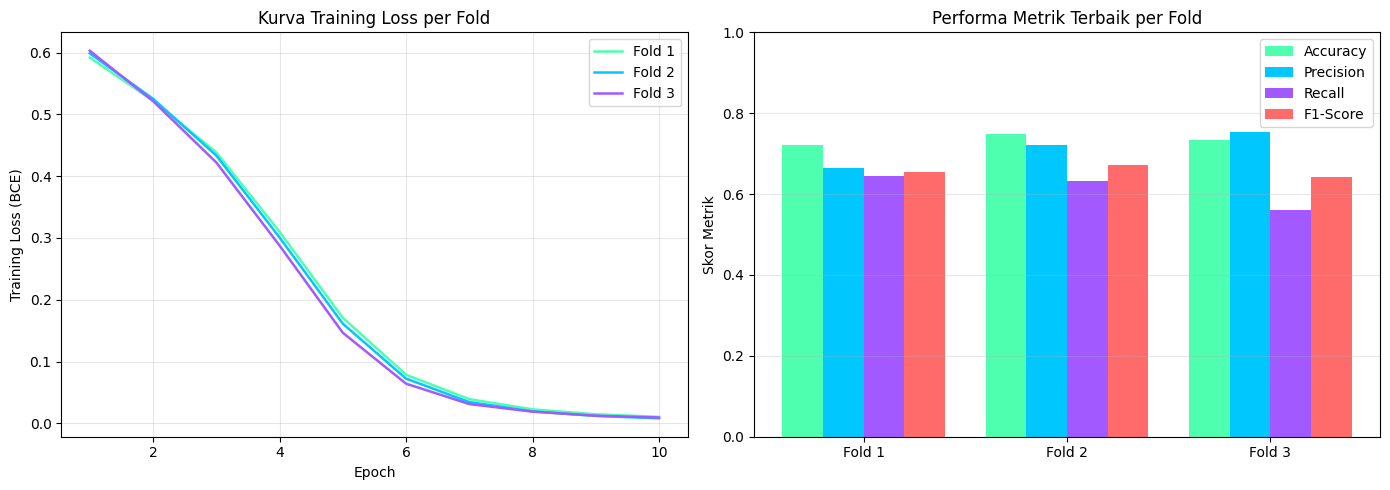


 [VISUALISASI] Confusion Matrix Terbaik dari Masing-Masing Fold...


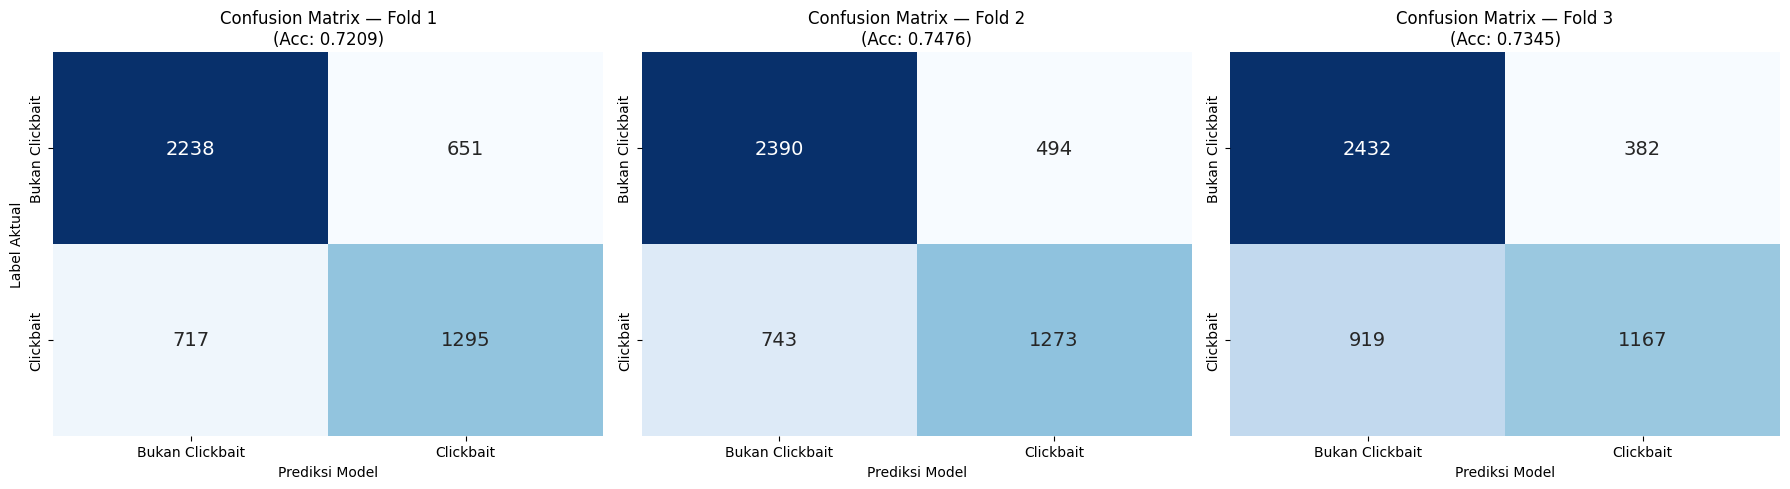

 Tiga Confusion Matrix berhasil di-generate dan disimpan ke Google Drive.


In [ ]:
# PROSES PELATIHAN — K-FOLD CROSS VALIDATION (K=3)

import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from sklearn.model_selection import KFold
from torch.utils.data import SubsetRandomSampler

# Konfigurasi Hiperparameter
K_FOLDS       = 3
EPOCHS        = 10
LR            = 2e-4
BATCH_SIZE    = 32
# Simpan model ke Google Drive agar tidak hilang saat sesi Colab berakhir
BEST_MODEL_PATH = '/content/drive/MyDrive/Skripsi/mamba_model_best.pth'

print("=" * 65)
print(f" MEMULAI K-FOLD CROSS VALIDATION (K={K_FOLDS}) | {EPOCHS} EPOCH")
print("=" * 65)

# Inisialisasi K-Fold dengan random_state tetap untuk reproducibility
kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=13)

# Variabel Perekam Global
best_overall_acc   = 0.0
best_epoch_global  = 0
best_fold_global   = 0

# Menyimpan metrik dan loss history
fold_results = {}
all_fold_loss_history = {}

# Menyimpan label dan prediksi TERBAIK dari MASING-MASING fold
best_labels_per_fold = {}
best_preds_per_fold  = {}

# Loop Utama K-Fold
for fold, (train_ids, test_ids) in enumerate(kfold.split(full_dataset)):
    print(f"\n [MEMASUKI FOLD {fold + 1}/{K_FOLDS}]")
    print("-" * 45)

    train_subsampler = SubsetRandomSampler(train_ids)
    test_subsampler  = SubsetRandomSampler(test_ids)

    train_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, sampler=train_subsampler)
    test_loader  = DataLoader(full_dataset, batch_size=BATCH_SIZE, sampler=test_subsampler)

    print(f" Data Latih : {len(train_ids)} sampel | Data Uji: {len(test_ids)} sampel")

    # Reinisialisasi model dan optimizer di setiap fold (reset bobot)
    model     = MambaClickbaitClassifier(vocab_size=tokenizer.vocab_size).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR)

    best_fold_acc   = 0.0
    best_fold_metrics = {'acc': 0.0, 'prec': 0.0, 'rec': 0.0, 'f1': 0.0}

    # Variabel sementara untuk menyimpan prediksi terbaik di fold ini
    temp_best_preds  = []
    temp_best_labels = []

    fold_loss_log = []   # loss history tiap epoch fold ini

    # Loop Epoch
    for epoch in range(EPOCHS):

        # Fase Training
        model.train()
        total_train_loss = 0.0

        for batch in train_loader:
            input_ids    = batch['input_ids'].to(device)
            batch_labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids)
            loss    = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        fold_loss_log.append(avg_train_loss)  # catat loss history

        # Fase Evaluasi
        model.eval()
        all_preds  = []
        all_labels = []

        with torch.no_grad():
            for batch in test_loader:
                input_ids    = batch['input_ids'].to(device)
                batch_labels = batch['label'].to(device)
                outputs      = model(input_ids)
                preds        = (outputs >= 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch_labels.cpu().numpy())

        acc  = accuracy_score(all_labels, all_preds)
        prec = precision_score(all_labels, all_preds, zero_division=0)
        rec  = recall_score(all_labels, all_preds, zero_division=0)
        f1   = f1_score(all_labels, all_preds, zero_division=0)

        # Cetak log setiap 5 epoch dan epoch terakhir
        if (epoch + 1) == 1 or (epoch + 1) % 5 == 0 or (epoch + 1) == EPOCHS:
            print(f"  Epoch {epoch+1:02d}/{EPOCHS} | "
                  f"Loss: {avg_train_loss:.4f} | "
                  f"Acc: {acc:.4f} | Prec: {prec:.4f} | "
                  f"Rec: {rec:.4f} | F1: {f1:.4f}")

        # Simpan SEMUA metrik dan prediksi terbaik epoch di fold ini
        if acc > best_fold_acc:
            best_fold_acc     = acc
            best_fold_metrics = {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1}

            # [TAMBAHAN] Simpan prediksi pada performa terbaiknya
            temp_best_preds  = all_preds.copy()
            temp_best_labels = all_labels.copy()

            # Jika akurasi ini tertinggi dari seluruh fold, simpan bobot ke Drive
            if acc > best_overall_acc:
                best_overall_acc  = acc
                best_epoch_global = epoch + 1
                best_fold_global  = fold + 1
                torch.save(model.state_dict(), BEST_MODEL_PATH)
                print(f"   [BEST MODEL TERSIMPAN] Fold {fold+1} | "
                      f"Epoch {epoch+1} | Akurasi: {acc:.4f}")

    # Simpan hasil fold ke dalam log global
    fold_results[fold + 1]          = best_fold_metrics
    all_fold_loss_history[fold + 1] = fold_loss_log

    # prediksi terbaik fold ini ke dictionary global
    best_preds_per_fold[fold + 1]  = temp_best_preds
    best_labels_per_fold[fold + 1] = temp_best_labels

    print(f"\n Selesai Fold {fold + 1} | "
          f"Acc: {best_fold_metrics['acc']:.4f} | "
          f"Prec: {best_fold_metrics['prec']:.4f} | "
          f"Rec: {best_fold_metrics['rec']:.4f} | "
          f"F1: {best_fold_metrics['f1']:.4f}")

# Rekapitulasi & Rata-rata K-Fold
print("\n" + "=" * 65)
print(" REKAP HASIL K-FOLD CROSS VALIDATION (K=3)")
print("=" * 65)
print(f" {'Fold':<8} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 55)

avg_acc  = avg_prec = avg_rec = avg_f1 = 0.0
for f, m in fold_results.items():
    print(f" Fold {f:<4} {m['acc']:>10.4f} {m['prec']:>10.4f} {m['rec']:>10.4f} {m['f1']:>10.4f}")
    avg_acc  += m['acc']
    avg_prec += m['prec']
    avg_rec  += m['rec']
    avg_f1   += m['f1']

n = len(fold_results)
avg_acc /= n; avg_prec /= n; avg_rec /= n; avg_f1 /= n

print("-" * 55)
print(f" {'RATA-RATA':<8} {avg_acc:>10.4f} {avg_prec:>10.4f} {avg_rec:>10.4f} {avg_f1:>10.4f}")
print("=" * 65)
print(f"\n MODEL TERBAIK: Fold {best_fold_global}, Epoch {best_epoch_global}")
print(f" Tersimpan di : {BEST_MODEL_PATH}")

# Visualisasi Kurva Loss & Bar Chart Metrik
print("\n [VISUALISASI] Kurva Loss per Epoch tiap Fold...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4fffb0', '#00c8ff', '#a259ff']
for fold_num, loss_hist in all_fold_loss_history.items():
    axes[0].plot(range(1, EPOCHS + 1), loss_hist,
                 label=f'Fold {fold_num}', color=colors[fold_num - 1], linewidth=1.8)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss (BCE)')
axes[0].set_title('Kurva Training Loss per Fold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Grafik Akurasi tiap Fold (bar chart)
fold_labels = [f'Fold {f}' for f in fold_results]
acc_vals    = [fold_results[f]['acc']  for f in fold_results]
prec_vals   = [fold_results[f]['prec'] for f in fold_results]
rec_vals    = [fold_results[f]['rec']  for f in fold_results]
f1_vals     = [fold_results[f]['f1']   for f in fold_results]

x    = np.arange(len(fold_labels))
w    = 0.2
axes[1].bar(x - 1.5*w, acc_vals,  w, label='Accuracy',  color='#4fffb0')
axes[1].bar(x - 0.5*w, prec_vals, w, label='Precision',  color='#00c8ff')
axes[1].bar(x + 0.5*w, rec_vals,  w, label='Recall',     color='#a259ff')
axes[1].bar(x + 1.5*w, f1_vals,   w, label='F1-Score',   color='#ff6b6b')
axes[1].set_xticks(x)
axes[1].set_xticklabels(fold_labels)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('Skor Metrik')
axes[1].set_title('Performa Metrik Terbaik per Fold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Skripsi/grafik_pelatihan.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualisasi Confusion Matrix Masing-Masing Fold Secara Berdampingan

print("\n [VISUALISASI] Confusion Matrix Terbaik dari Masing-Masing Fold...")

# Buat canvas figure dengan 1 baris dan 3 kolom (karena K=3)
fig_cm, axes_cm = plt.subplots(1, K_FOLDS, figsize=(18, 5))

for i, fold_num in enumerate(range(1, K_FOLDS + 1)):
    labels = best_labels_per_fold[fold_num]
    preds  = best_preds_per_fold[fold_num]

    # Hitung matriks kebingungan
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()

    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Bukan Clickbait', 'Clickbait'],
                yticklabels=['Bukan Clickbait', 'Clickbait'],
                ax=axes_cm[i], cbar=False,
                annot_kws={"size": 14})

    axes_cm[i].set_title(f'Confusion Matrix — Fold {fold_num}\n(Acc: {fold_results[fold_num]["acc"]:.4f})')
    axes_cm[i].set_xlabel('Prediksi Model')
    if i == 0:
        axes_cm[i].set_ylabel('Label Aktual') # Hanya tampil di plot paling kiri agar rapi

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Skripsi/confusion_matrix_all_folds.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Tiga Confusion Matrix berhasil di-generate dan disimpan ke Google Drive.")


 [VISUALISASI] Menyimpan Confusion Matrix Terbaik dari Masing-Masing Fold secara terpisah...


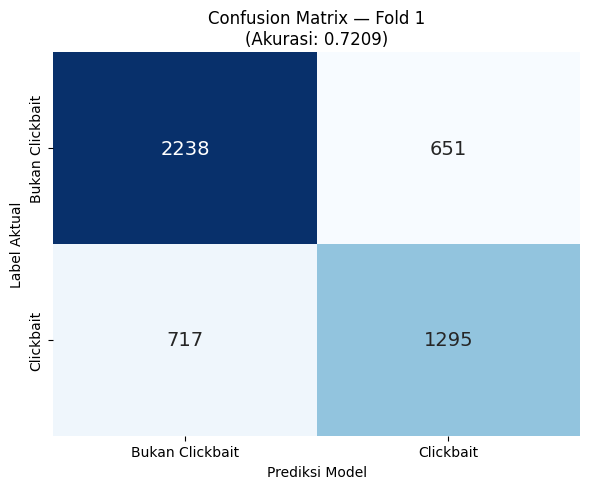


 Output Fold 1:
   True Positive  (TP): 1295  | False Positive (FP): 651
   True Negative  (TN): 2238  | False Negative (FN): 717
 -> Gambar berhasil disimpan ke: /content/drive/MyDrive/Skripsi/confusion_matrix_fold_1.png


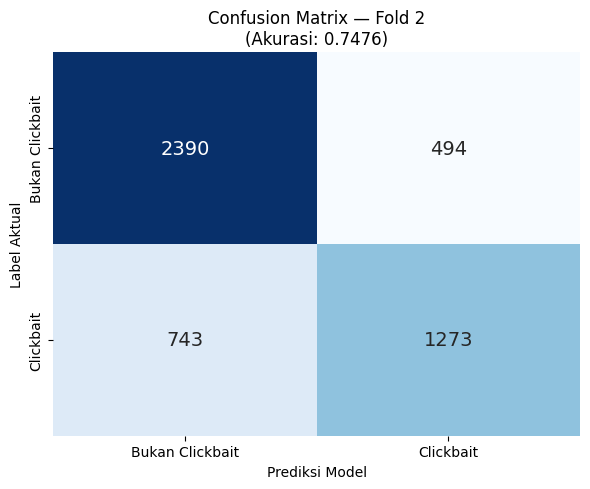


 Output Fold 2:
   True Positive  (TP): 1273  | False Positive (FP): 494
   True Negative  (TN): 2390  | False Negative (FN): 743
 -> Gambar berhasil disimpan ke: /content/drive/MyDrive/Skripsi/confusion_matrix_fold_2.png


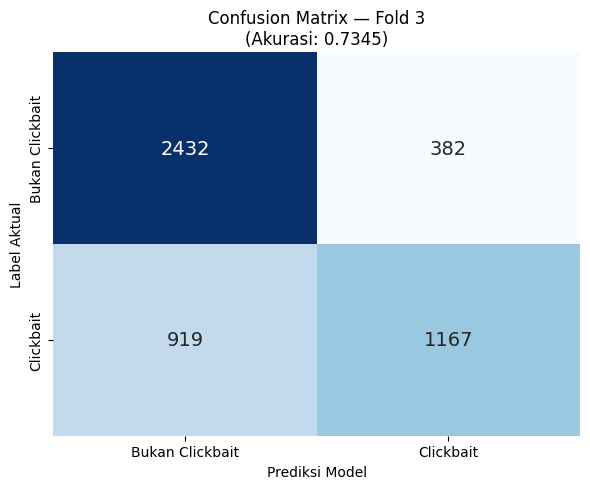


 Output Fold 3:
   True Positive  (TP): 1167  | False Positive (FP): 382
   True Negative  (TN): 2432  | False Negative (FN): 919
 -> Gambar berhasil disimpan ke: /content/drive/MyDrive/Skripsi/confusion_matrix_fold_3.png

 Seluruh Confusion Matrix berhasil di-generate secara terpisah.


In [ ]:
# Visualisasi Confusion Matrix Masing-Masing Fold Secara Terpisah
print("\n [VISUALISASI] Menyimpan Confusion Matrix Terbaik dari Masing-Masing Fold secara terpisah...")

for fold_num in range(1, K_FOLDS + 1):
    labels = best_labels_per_fold[fold_num]
    preds  = best_preds_per_fold[fold_num]

    # Hitung matriks kebingungan
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()

    # Buat canvas baru (figure) untuk setiap fold
    fig, ax = plt.subplots(figsize=(6, 5))

    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Bukan Clickbait', 'Clickbait'],
                yticklabels=['Bukan Clickbait', 'Clickbait'],
                ax=ax, cbar=False,
                annot_kws={"size": 14})

    ax.set_title(f'Confusion Matrix — Fold {fold_num}\n(Akurasi: {fold_results[fold_num]["acc"]:.4f})')
    ax.set_xlabel('Prediksi Model')
    ax.set_ylabel('Label Aktual')

    plt.tight_layout()

    # Simpan dengan nama file yang unik untuk masing-masing fold
    save_path = f'/content/drive/MyDrive/Skripsi/confusion_matrix_fold_{fold_num}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    # Menampilkan rekap angka di terminal
    print(f"\n Output Fold {fold_num}:")
    print(f"   True Positive  (TP): {tp}  | False Positive (FP): {fp}")
    print(f"   True Negative  (TN): {tn}  | False Negative (FN): {fn}")
    print(f" -> Gambar berhasil disimpan ke: {save_path}")

print("\n Seluruh Confusion Matrix berhasil di-generate secara terpisah.")

In [ ]:
!pip install pyngrok -q

## Aplikasi Flask (Antarmuka Web)

In [ ]:
# APLIKASI FLASK — ANTARMUKA WEB REAL-TIME

import os
import re
import urllib.request
from flask import Flask, request, jsonify, render_template_string
import threading
import logging
from newspaper import Article
import torch
import time
from pyngrok import ngrok, conf

ngrok.set_auth_token("MASUKKAN_TOKEN_NGROK_ANDA_DI_SINI")
ngrok.kill()

# Memuat Model Terbaik dari Google Drive
BEST_MODEL_PATH = '/content/drive/MyDrive/Skripsi/mamba_model_best.pth'
print(" [SISTEM] Memuat model terbaik Mamba dari Google Drive...")
model_final = MambaClickbaitClassifier(vocab_size=tokenizer.vocab_size).to(device)
model_final.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model_final.eval()
print("Model siap digunakan.")

log = logging.getLogger('werkzeug')
log.setLevel(logging.ERROR)
app = Flask(__name__)

HTML_TEMPLATE = """
<!DOCTYPE html>
<html lang="id">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Deteksi Clickbait Berita Indonesia</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Sora:wght@300;400;500;600;700&family=JetBrains+Mono:wght@400;500&display=swap" rel="stylesheet">
<style>
  :root {
    --bg-deep:    #03050f;
    --bg-mid:     #080c1e;
    --accent1:    #4fffb0;
    --accent2:    #00c8ff;
    --accent3:    #a259ff;
    --warn:       #ff6b6b;
    --glass-bg:   rgba(255,255,255,0.04);
    --glass-border: rgba(255,255,255,0.10);
    --glass-hover: rgba(255,255,255,0.07);
    --text-primary: #e8f0fe;
    --text-muted:   #7a8ba8;
    --shadow-glow: 0 0 40px rgba(79,255,176,0.15);
  }
  *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }
  body { font-family: 'Sora', sans-serif; background: var(--bg-deep); color: var(--text-primary); min-height: 100vh; }
  .bg-orbs { position: fixed; inset: 0; z-index: 0; pointer-events: none; }
  .orb { position: absolute; border-radius: 50%; filter: blur(90px); opacity: 0.18; animation: drift 14s ease-in-out infinite alternate; }
  .orb-1 { width: 500px; height: 500px; background: var(--accent3); top: -10%; left: -10%; }
  .orb-2 { width: 400px; height: 400px; background: var(--accent2); top: 40%; right: -8%; animation-delay: -5s; }
  .orb-3 { width: 350px; height: 350px; background: var(--accent1); bottom: -5%; left: 30%; animation-delay: -9s; }
  @keyframes drift { from { transform: translate(0,0) scale(1); } to { transform: translate(30px,-20px) scale(1.06); } }
  .wrapper { position: relative; z-index: 2; max-width: 820px; margin: 0 auto; padding: 40px 20px 80px; }
  header { text-align: center; margin-bottom: 48px; animation: fadeDown 0.7s ease both; }
  .logo-badge { display: inline-flex; align-items: center; gap: 10px; background: var(--glass-bg); border: 1px solid var(--glass-border); border-radius: 999px; padding: 8px 20px; font-size: 12px; letter-spacing: 0.15em; text-transform: uppercase; color: var(--accent1); margin-bottom: 24px; }
  h1 { font-size: clamp(2rem,5vw,3.2rem); font-weight: 700; background: linear-gradient(135deg,var(--accent1) 0%,var(--accent2) 50%,var(--accent3) 100%); -webkit-background-clip: text; -webkit-text-fill-color: transparent; margin-bottom: 14px; }
  .subtitle { color: var(--text-muted); font-size: 15px; max-width: 500px; margin: 0 auto; line-height: 1.7; }
  .tech-pills { display: flex; flex-wrap: wrap; justify-content: center; gap: 8px; margin-top: 20px; }
  .pill { font-size: 11px; font-family: 'JetBrains Mono', monospace; background: rgba(79,255,176,0.08); border: 1px solid rgba(79,255,176,0.2); color: var(--accent1); border-radius: 999px; padding: 4px 12px; }
  .glass-card { background: var(--glass-bg); border: 1px solid var(--glass-border); border-radius: 20px; backdrop-filter: blur(20px); padding: 32px; transition: border-color 0.3s; }
  .glass-card:focus-within { border-color: rgba(79,255,176,0.3); box-shadow: var(--shadow-glow); }
  .mode-toggle { display: flex; background: rgba(0,0,0,0.3); border: 1px solid var(--glass-border); border-radius: 12px; padding: 4px; margin-bottom: 28px; gap: 4px; }
  .mode-btn { flex: 1; background: none; border: none; color: var(--text-muted); font-family: 'Sora', sans-serif; font-size: 13px; font-weight: 500; padding: 10px 16px; border-radius: 9px; cursor: pointer; transition: all 0.25s; display: flex; align-items: center; justify-content: center; gap: 8px; }
  .mode-btn.active { background: linear-gradient(135deg,rgba(79,255,176,0.15),rgba(0,200,255,0.15)); color: var(--accent1); border: 1px solid rgba(79,255,176,0.3); }
  .field-label { font-size: 12px; letter-spacing: 0.1em; text-transform: uppercase; color: var(--text-muted); margin-bottom: 10px; display: block; }
  .input-wrap { position: relative; }
  .input-wrap .prefix-icon { position: absolute; left: 16px; top: 50%; transform: translateY(-50%); color: var(--text-muted); }
  input[type="text"], textarea { width: 100%; background: rgba(0,0,0,0.25); border: 1px solid var(--glass-border); border-radius: 12px; color: var(--text-primary); font-family: 'Sora', sans-serif; font-size: 14px; padding: 14px 16px 14px 44px; outline: none; transition: all 0.25s; }
  textarea { padding: 14px 16px; resize: vertical; min-height: 100px; }
  input:focus, textarea:focus { border-color: rgba(79,255,176,0.4); box-shadow: 0 0 0 3px rgba(79,255,176,0.07); }
  .text-fields { display: none; }
  .text-fields.active { display: block; }
  .url-field { display: none; }
  .url-field.active { display: block; }
  .row { display: flex; gap: 16px; margin-top: 20px; }
  .row > * { flex: 1; }
  .select-wrap { position: relative; }
  select { width: 100%; background: rgba(0,0,0,0.25); border: 1px solid var(--glass-border); border-radius: 12px; color: var(--text-primary); font-family: 'Sora', sans-serif; font-size: 14px; padding: 14px 40px 14px 16px; outline: none; appearance: none; cursor: pointer; }
  select:focus { border-color: rgba(79,255,176,0.4); }
  .select-arrow { position: absolute; right: 14px; top: 50%; transform: translateY(-50%); pointer-events: none; color: var(--text-muted); }
  .btn-analyze { margin-top: 28px; width: 100%; background: linear-gradient(135deg,var(--accent1),var(--accent2)); border: none; border-radius: 12px; color: #03050f; font-family: 'Sora', sans-serif; font-size: 15px; font-weight: 700; padding: 16px; cursor: pointer; transition: all 0.2s; }
  .btn-analyze:hover:not(:disabled) { transform: translateY(-2px); box-shadow: 0 12px 32px rgba(79,255,176,0.3); }
  .btn-analyze:disabled { opacity: 0.5; cursor: not-allowed; }
  .loader-area { display: none; text-align: center; padding: 40px 20px; }
  .loader-area.active { display: block; }
  .loader-ring { width: 52px; height: 52px; border: 3px solid rgba(79,255,176,0.15); border-top-color: var(--accent1); border-radius: 50%; animation: spin 0.8s linear infinite; margin: 0 auto 16px; }
  .loader-text { font-size: 13px; color: var(--text-muted); font-family: 'JetBrains Mono', monospace; }
  .loader-steps { margin-top: 12px; display: flex; flex-direction: column; gap: 6px; align-items: center; }
  .step-item { font-size: 12px; color: var(--text-muted); padding: 4px 14px; border-radius: 999px; border: 1px solid transparent; font-family: 'JetBrains Mono', monospace; }
  .step-item.active { color: var(--accent1); border-color: rgba(79,255,176,0.3); background: rgba(79,255,176,0.07); }
  .step-item.done { color: rgba(79,255,176,0.5); }
  @keyframes spin { to { transform: rotate(360deg); } }
  .result-area { display: none; margin-top: 24px; animation: fadeUp 0.5s ease both; }
  .result-area.active { display: block; }
  .verdict-banner { border-radius: 16px; padding: 28px 32px; display: flex; align-items: center; gap: 20px; margin-bottom: 20px; }
  .verdict-banner.clickbait { background: linear-gradient(135deg,rgba(255,107,107,0.12),rgba(255,107,107,0.05)); border: 1px solid rgba(255,107,107,0.35); }
  .verdict-banner.not-clickbait { background: linear-gradient(135deg,rgba(79,255,176,0.12),rgba(79,255,176,0.05)); border: 1px solid rgba(79,255,176,0.35); }
  .verdict-icon { font-size: 40px; }
  .verdict-text h2 { font-size: 22px; font-weight: 700; margin-bottom: 4px; }
  .verdict-banner.clickbait .verdict-text h2 { color: #ff8e8e; }
  .verdict-banner.not-clickbait .verdict-text h2 { color: var(--accent1); }
  .verdict-text p { font-size: 13px; color: var(--text-muted); }
  .gauge-card { padding: 24px 28px; border-radius: 16px; margin-bottom: 16px; }
  .gauge-header { display: flex; justify-content: space-between; align-items: center; margin-bottom: 16px; }
  .gauge-label { font-size: 12px; text-transform: uppercase; color: var(--text-muted); }
  .gauge-value { font-family: 'JetBrains Mono', monospace; font-size: 28px; font-weight: 500; }
  .gauge-track { height: 10px; background: rgba(255,255,255,0.06); border-radius: 999px; overflow: hidden; }
  .gauge-fill { height: 100%; border-radius: 999px; transition: width 1.2s cubic-bezier(0.22,1,0.36,1); width: 0%; }
  .gauge-fill.clickbait { background: linear-gradient(90deg,#ff9a9a,var(--warn)); }
  .gauge-fill.not-clickbait { background: linear-gradient(90deg,#4fffb0,var(--accent2)); }
  .analysis-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 12px; margin-bottom: 16px; }
  .stat-tile { background: rgba(0,0,0,0.2); border: 1px solid var(--glass-border); border-radius: 12px; padding: 16px 18px; }
  .stat-tile .t-label { font-size: 11px; text-transform: uppercase; color: var(--text-muted); margin-bottom: 6px; }
  .stat-tile .t-val { font-size: 14px; font-weight: 600; font-family: 'JetBrains Mono', monospace; }
  .reasoning-card { border-radius: 14px; padding: 22px 24px; margin-bottom: 16px; }
  .section-head { font-size: 11px; text-transform: uppercase; color: var(--text-muted); margin-bottom: 14px; display: flex; align-items: center; gap: 8px; }
  .section-head::after { content: ''; flex: 1; height: 1px; background: var(--glass-border); }
  .reasoning-text { font-size: 14px; line-height: 1.75; font-weight: 300; }
  .indicators { display: flex; flex-wrap: wrap; gap: 8px; margin-top: 16px; }
  .indicator-tag { font-size: 12px; padding: 5px 12px; border-radius: 999px; font-family: 'JetBrains Mono', monospace; }
  .indicator-tag.red   { background: rgba(255,107,107,0.1); border: 1px solid rgba(255,107,107,0.3); color: #ff8e8e; }
  .indicator-tag.green { background: rgba(79,255,176,0.1); border: 1px solid rgba(79,255,176,0.3); color: var(--accent1); }
  .model-info-bar { display: flex; justify-content: space-between; align-items: center; padding: 14px 18px; border-radius: 10px; background: rgba(0,0,0,0.2); border: 1px solid var(--glass-border); font-size: 12px; color: var(--text-muted); font-family: 'JetBrains Mono', monospace; margin-bottom: 16px; }
  .model-info-bar span { color: var(--accent1); }
  .btn-reset { width: 100%; background: none; border: 1px solid var(--glass-border); color: var(--text-muted); font-family: 'Sora', sans-serif; font-size: 13px; padding: 12px; border-radius: 10px; cursor: pointer; transition: all 0.25s; }
  .btn-reset:hover { border-color: rgba(255,255,255,0.2); color: var(--text-primary); }
  .error-msg { display: none; margin-top: 16px; padding: 14px 18px; border-radius: 10px; background: rgba(255,107,107,0.08); border: 1px solid rgba(255,107,107,0.25); color: #ff8e8e; font-size: 13px; }
  .error-msg.active { display: block; }
  footer { text-align: center; margin-top: 48px; padding-top: 24px; border-top: 1px solid var(--glass-border); color: var(--text-muted); font-size: 12px; line-height: 2; }
  footer .foot-mono { font-family: 'JetBrains Mono', monospace; color: rgba(79,255,176,0.6); }
  @keyframes fadeDown { from { opacity:0; transform:translateY(-20px); } to { opacity:1; transform:translateY(0); } }
  @keyframes fadeUp   { from { opacity:0; transform:translateY(20px);  } to { opacity:1; transform:translateY(0); } }
</style>
</head>
<body>
<div class="bg-orbs"><div class="orb orb-1"></div><div class="orb orb-2"></div><div class="orb orb-3"></div></div>
<div class="wrapper">
  <header>
    <div class="logo-badge"><span>🛡️</span> ClickShield — NLP Detection System</div>
    <h1>Deteksi Clickbait<br>Berita Indonesia</h1>
    <p class="subtitle">Klasifikasi judul berita clickbait menggunakan arsitektur <strong>Mamba Selective State Space Model</strong> berbasis IndoBERTweet tokenization.</p>
    <div class="tech-pills">
      <span class="pill">Mamba SSM</span>
      <span class="pill">IndoBERTweet</span>
      <span class="pill">K-Fold CV (k=3)</span>
      <span class="pill">Flask API</span>
      <span class="pill">NLP Bahasa Indonesia</span>
    </div>
  </header>

  <div class="glass-card">
    <div class="mode-toggle">
      <button class="mode-btn active" onclick="setMode('url')" id="btn-url">
        <svg viewBox="0 0 24 24" width="15" height="15" fill="none" stroke="currentColor" stroke-width="2"><path d="M10 13a5 5 0 0 0 7.54.54l3-3a5 5 0 0 0-7.07-7.07l-1.72 1.71"/><path d="M14 11a5 5 0 0 0-7.54-.54l-3 3a5 5 0 0 0 7.07 7.07l1.71-1.71"/></svg>
        Input URL Berita
      </button>
      <button class="mode-btn" onclick="setMode('text')" id="btn-text">
        <svg viewBox="0 0 24 24" width="15" height="15" fill="none" stroke="currentColor" stroke-width="2"><path d="M11 4H4a2 2 0 0 0-2 2v14a2 2 0 0 0 2 2h14a2 2 0 0 0 2-2v-7"/><path d="M18.5 2.5a2.121 2.121 0 0 1 3 3L12 15l-4 1 1-4 9.5-9.5z"/></svg>
        Input Manual
      </button>
    </div>

    <div class="url-field active" id="url-field">
      <label class="field-label">Tautan URL Berita</label>
      <div class="input-wrap">
        <span class="prefix-icon">🔗</span>
        <input type="text" id="url-input" placeholder="https://www.detik.com/berita/..." />
      </div>
      <p style="font-size:12px;color:var(--text-muted);margin-top:8px;">⚡ Sistem akan mengekstraksi judul &amp; isi berita secara otomatis via web scraping.</p>
    </div>

    <div class="text-fields" id="text-fields">
      <div style="margin-bottom:20px">
        <label class="field-label">Judul Berita</label>
        <div class="input-wrap">
          <span class="prefix-icon">📰</span>
          <input type="text" id="title-input" placeholder="Masukkan judul berita di sini..." />
        </div>
      </div>
      <div>
        <label class="field-label">Isi / Konten Berita</label>
        <textarea id="content-input" placeholder="Tempelkan isi artikel berita di sini..."></textarea>
      </div>
    </div>

    <div class="row" style="margin-top:24px">
      <div>
        <label class="field-label">Model Terpilih</label>
        <div style="background:rgba(0,0,0,0.25);border:1px solid var(--glass-border);border-radius:12px;color:var(--text-primary);font-family:'Sora',sans-serif;font-size:14px;padding:14px 16px;">
          🧠 Mamba SSM (K-Fold, k=3)
        </div>
      </div>
      <div>
        <label class="field-label">Ambang Batas (Threshold)</label>
        <div class="select-wrap">
          <select id="threshold-select">
            <option value="0.5">0.50 — Standar</option>
            <option value="0.6">0.60 — Konservatif</option>
            <option value="0.4">0.40 — Agresif</option>
          </select>
          <span class="select-arrow">▾</span>
        </div>
      </div>
    </div>

    <button class="btn-analyze" id="btn-analyze" onclick="analyze()">🔍 &nbsp; Analisis Sekarang</button>
    <div class="error-msg" id="error-msg"></div>
  </div>

  <div class="loader-area glass-card" id="loader-area" style="margin-top:24px;">
    <div class="loader-ring"></div>
    <div class="loader-text">Memproses dengan Mamba SSM...</div>
    <div class="loader-steps">
      <div class="step-item" id="step-1">① Web Scraping Teks</div>
      <div class="step-item" id="step-2">② Tokenisasi IndoBERTweet (WordPiece)</div>
      <div class="step-item" id="step-3">③ Embedding vektor 256-dim</div>
      <div class="step-item" id="step-4">④ Selective State Space Scan</div>
      <div class="step-item" id="step-5">⑤ LayerNorm → FC → Sigmoid</div>
    </div>
  </div>

  <div class="result-area" id="result-area">
    <div class="verdict-banner" id="verdict-banner">
      <div class="verdict-icon" id="verdict-icon"></div>
      <div class="verdict-text">
        <h2 id="verdict-title"></h2>
        <p id="verdict-subtitle"></p>
      </div>
    </div>

    <div class="model-info-bar">
      <span>MODEL: <span id="result-model"></span></span>
      <span>THRESHOLD: <span id="result-threshold"></span></span>
      <span>ARCH: <span>Mamba SSM</span></span>
    </div>

    <div class="glass-card gauge-card" style="margin-bottom:16px;">
      <div class="gauge-header">
        <span class="gauge-label">Probabilitas Clickbait</span>
        <span class="gauge-value" id="gauge-value-text">0%</span>
      </div>
      <div class="gauge-track"><div class="gauge-fill" id="gauge-fill"></div></div>
      <div style="display:flex;justify-content:space-between;margin-top:8px;">
        <span style="font-size:11px;color:var(--accent1);font-family:'JetBrains Mono',monospace;">Bukan Clickbait</span>
        <span style="font-size:11px;color:var(--warn);font-family:'JetBrains Mono',monospace;">Clickbait</span>
      </div>
    </div>

    <div class="analysis-grid" id="stat-grid"></div>

    <div class="glass-card reasoning-card" style="margin-bottom:16px;">
      <div class="section-head">Analisis Linguistik Model</div>
      <div class="reasoning-text" id="reasoning-text"></div>
      <div class="indicators" id="indicators"></div>
    </div>

    <button class="btn-reset" onclick="resetAll()">↩ Analisis Berita Lain</button>
  </div>

  <footer>
    <div>Skripsi — Program Studi Teknik Informatika, Universitas Tarumanagara 2026</div>
    <div class="foot-mono">Ridhwan Ardiyansyah · NIM: 535220114</div>
    <div style="margin-top:4px;font-size:11px;opacity:0.5">Klasifikasi Berita ClickBait Menggunakan Mamba Selective State Space Model</div>
  </footer>
</div>

<script>
  let currentMode = 'url';
  function setMode(mode) {
    currentMode = mode;
    document.getElementById('url-field').classList.toggle('active', mode === 'url');
    document.getElementById('text-fields').classList.toggle('active', mode === 'text');
    document.getElementById('btn-url').classList.toggle('active', mode === 'url');
    document.getElementById('btn-text').classList.toggle('active', mode === 'text');
  }
  function showError(msg) {
    const el = document.getElementById('error-msg');
    el.textContent = '⚠️ ' + msg;
    el.classList.add('active');
  }
  function clearError() { document.getElementById('error-msg').classList.remove('active'); }
  function setLoaderStep(n) {
    for (let i = 1; i <= 5; i++) {
      const el = document.getElementById('step-' + i);
      if (i < n) el.className = 'step-item done';
      else if (i === n) el.className = 'step-item active';
      else el.className = 'step-item';
    }
  }
  async function animateLoader() {
    for (let i = 1; i <= 5; i++) { setLoaderStep(i); await new Promise(r => setTimeout(r, 400)); }
  }
  async function analyze() {
    clearError();
    let title = '', content = '';
    if (currentMode === 'url') {
      title = document.getElementById('url-input').value.trim();
      if (!title) { showError('Masukkan URL berita terlebih dahulu.'); return; }
      const _lo = title.toLowerCase();
      if (!(_lo.startsWith('http://') || _lo.startsWith('https://')) || title.indexOf('.') === -1 || title.indexOf(' ') !== -1) { showError('Format URL tidak valid. Contoh yang benar: https://namasitus.com/judul-berita'); return; }
    } else {
      title   = document.getElementById('title-input').value.trim();
      content = document.getElementById('content-input').value.trim();
      if (!title) { showError('Masukkan judul berita terlebih dahulu.'); return; }
      const combinedTxt = (title + ' ' + content).trim();
      if (combinedTxt.length < 15) { showError('Teks terlalu pendek. Masukkan judul berita yang lebih lengkap (minimal 15 karakter).'); return; }
      if (combinedTxt.split(' ').filter(Boolean).length < 3) { showError('Masukkan minimal 3 kata agar berita dapat dianalisis.'); return; }
      const _letters = (combinedTxt.match(/[a-zA-Z]/g) || []).length;
      const _nonspace = combinedTxt.replace(/ /g, '').length;
      if (_nonspace === 0 || _letters / _nonspace < 0.5) { showError('Input tidak mengandung kalimat bermakna (terlalu banyak angka atau simbol).'); return; }
    }
    const threshold = parseFloat(document.getElementById('threshold-select').value);
    document.getElementById('loader-area').classList.add('active');
    document.getElementById('result-area').classList.remove('active');
    document.getElementById('btn-analyze').disabled = true;
    const loaderAnim = animateLoader();
    try {
      const response = await fetch('/api/predict', {
        method: 'POST',
        headers: { 'Content-Type': 'application/json' },
        body: JSON.stringify({ title_url: title, content: content, mode: currentMode })
      });
      if (!response.ok) throw new Error('API error: Gagal terhubung ke backend.');
      const data = await response.json();
      if (data.error) throw new Error(data.error);
      await loaderAnim;
      const isClickbait = data.probability >= threshold;
      const prob = data.probability;
      let confLvl = "Sedang";
      if (prob > 0.85 || prob < 0.15) confLvl = "Sangat Tinggi";
      else if (prob > 0.65 || prob < 0.35) confLvl = "Tinggi";
      const reasoningTxt = isClickbait
        ? "Berdasarkan evaluasi sekuensial Mamba, model mendeteksi adanya manipulasi sentimen dan pola curiosity gap. Struktur kalimat tidak merepresentasikan esensi berita secara langsung."
        : "Pemindaian model tidak menemukan anomali provokatif. Susunan kalimat bersifat faktual, objektif, dan representatif terhadap substansi informasi.";
      const indicatorsArr = isClickbait ? ["Sensasionalisme","Curiosity Gap","Over-Promise"] : ["Faktual","Objektif","Representatif"];
      const indTypes      = isClickbait ? ["red","red","red"] : ["green","green","green"];
      displayResult(isClickbait, prob, threshold, confLvl, reasoningTxt, indicatorsArr, indTypes);
    } catch (err) {
      document.getElementById('loader-area').classList.remove('active');
      document.getElementById('btn-analyze').disabled = false;
      showError(err.message);
    }
  }
  function displayResult(isClickbait, prob, threshold, confLvl, reasoningTxt, indicatorsArr, indTypes) {
    document.getElementById('loader-area').classList.remove('active');
    document.getElementById('btn-analyze').disabled = false;
    const probPct = Math.round(prob * 100);
    const banner  = document.getElementById('verdict-banner');
    banner.className = 'verdict-banner ' + (isClickbait ? 'clickbait' : 'not-clickbait');
    document.getElementById('verdict-icon').textContent     = isClickbait ? '⚠️' : '✅';
    document.getElementById('verdict-title').textContent    = isClickbait ? 'TERDETEKSI CLICKBAIT' : 'BUKAN CLICKBAIT';
    document.getElementById('verdict-subtitle').textContent = isClickbait
      ? 'Judul berita ini mengandung indikasi manipulasi informasi untuk mendongkrak trafik.'
      : 'Judul berita ini dinilai faktual dan merepresentasikan isi dengan baik.';
    //Teks model diperbarui
    document.getElementById('result-model').textContent     = "Mamba K-Fold (k=3)";
    document.getElementById('result-threshold').textContent = threshold.toFixed(2);
    const gaugeVal  = document.getElementById('gauge-value-text');
    const gaugeFill = document.getElementById('gauge-fill');
    gaugeVal.textContent  = probPct + '%';
    gaugeFill.className   = 'gauge-fill ' + (isClickbait ? 'clickbait' : 'not-clickbait');
    gaugeVal.style.color  = isClickbait ? 'var(--warn)' : 'var(--accent1)';
    setTimeout(() => { gaugeFill.style.width = probPct + '%'; }, 100);
    const grid = document.getElementById('stat-grid');
    const confColor = confLvl !== 'Sedang' ? 'var(--accent1)' : 'var(--accent2)';
    grid.innerHTML = `
      <div class="stat-tile"><div class="t-label">Probabilitas Matematis</div><div class="t-val" style="color:${isClickbait?'var(--warn)':'var(--accent1)'}">${prob.toFixed(4)}</div></div>
      <div class="stat-tile"><div class="t-label">Tingkat Keyakinan</div><div class="t-val" style="color:${confColor}">${confLvl}</div></div>
      <div class="stat-tile"><div class="t-label">Evaluasi Threshold</div><div class="t-val">${prob.toFixed(2)} ${prob>=threshold?'≥':'<'} ${threshold.toFixed(2)}</div></div>
      <div class="stat-tile"><div class="t-label">Keputusan Akhir</div><div class="t-val" style="color:${isClickbait?'var(--warn)':'var(--accent1)'}">${isClickbait?'CLICKBAIT':'NORMAL'}</div></div>`;
    document.getElementById('reasoning-text').textContent = reasoningTxt;
    const indEl = document.getElementById('indicators');
    indEl.innerHTML = '';
    indicatorsArr.forEach((ind,i) => {
      const tag = document.createElement('span');
      tag.className = 'indicator-tag ' + indTypes[i];
      tag.textContent = ind;
      indEl.appendChild(tag);
    });
    document.getElementById('result-area').classList.add('active');
    document.getElementById('result-area').scrollIntoView({ behavior:'smooth', block:'start' });
  }
  function resetAll() {
    document.getElementById('result-area').classList.remove('active');
    document.getElementById('loader-area').classList.remove('active');
    if (currentMode === 'url') document.getElementById('url-input').value = '';
    else { document.getElementById('title-input').value = ''; document.getElementById('content-input').value = ''; }
    clearError();
    window.scrollTo({ top:0, behavior:'smooth' });
  }
</script>
</body>
</html>
"""

from urllib.parse import urlparse

# Parameter Validasi Input
MIN_WORDS_MANUAL  = 3      # judul manual minimal 3 kata
MIN_CHARS_MANUAL  = 15     # judul manual minimal 15 karakter
MIN_WORDS_SCRAPED = 30     # hasil scraping URL minimal 30 kata agar layak dianalisis
MAX_CHARS_INPUT   = 10000  # batas atas panjang input

def is_valid_url(url):
    """Validasi format URL: skema http/https dan domain ber-titik yang wajar."""
    try:
        parsed = urlparse(url)
    except Exception:
        return False
    if parsed.scheme not in ('http', 'https'):
        return False
    if not parsed.netloc or '.' not in parsed.netloc:
        return False
    if re.search(r'\s', parsed.netloc):
        return False
    return True

def is_meaningful_text(text, min_words, min_chars):
    """Pastikan teks bukan asal-asalan: cukup panjang, cukup kata, dan didominasi huruf."""
    text = (text or '').strip()
    if len(text) < min_chars:
        return False, f"Teks terlalu pendek. Masukkan minimal {min_chars} karakter."
    words = [w for w in re.split(r'\s+', text) if w]
    if len(words) < min_words:
        return False, f"Teks terlalu sedikit. Masukkan minimal {min_words} kata."
    letters   = sum(c.isalpha() for c in text)
    non_space = sum(not c.isspace() for c in text)
    if non_space == 0 or (letters / non_space) < 0.5:
        return False, "Input tidak mengandung kalimat bermakna (terlalu banyak angka/simbol)."
    if len(set(text.replace(' ', ''))) <= 2:
        return False, "Input terindikasi bukan kalimat yang valid."
    return True, ""

def clean_input_text(text):
    # Normalisasi: hapus karakter non-alfanumerik kecuali spasi dan tanda baca dasar
    text = re.sub(r'[^a-zA-Z0-9\s.,!?;:\'\"-]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip().lower()

@app.route('/')
def home():
    return render_template_string(HTML_TEMPLATE)

@app.route('/api/predict', methods=['POST'])
def predict():
    data        = request.json or {}
    input_str   = (data.get('title_url') or '').strip()
    content_str = (data.get('content') or '').strip()
    mode        = (data.get('mode') or '').strip()

    print("\n" + "="*50)
    print(" [SISTEM] Menerima instruksi analisis baru!")

    # VALIDASI DASAR
    if not input_str:
        return jsonify({"error": "Input tidak boleh kosong."}), 400
    if (len(input_str) + len(content_str)) > MAX_CHARS_INPUT:
        return jsonify({"error": f"Input terlalu panjang (maksimal {MAX_CHARS_INPUT} karakter)."}), 400

    is_url_mode = (mode == 'url') or input_str.startswith('http://') or input_str.startswith('https://')

    if is_url_mode:
        # VALIDASI MODE URL
        if not is_valid_url(input_str):
            return jsonify({"error": "Format URL tidak valid. Gunakan alamat lengkap, contoh: https://situs.com/judul-berita"}), 400
        print(f" [1/5] URL valid. Memulai Web Scraping: {input_str}")
        try:
            article = Article(input_str)
            article.download()
            article.parse()
        except Exception as e:
            print(f" [ERROR] Scraping gagal: {e}")
            return jsonify({"error": "Gagal mengunduh artikel dari URL. Periksa kembali tautan atau coba berita lain."}), 400

        # Hasil scraping harus cukup berisi
        scraped    = f"{article.title} {article.text}".strip()
        word_count = len(scraped.split())
        if word_count < MIN_WORDS_SCRAPED:
            print(f" [ERROR] Konten hasil scraping terlalu sedikit ({word_count} kata).")
            return jsonify({"error": "Konten dari URL terlalu sedikit atau tidak dapat diekstrak (kemungkinan halaman berbayar/paywall atau bukan halaman berita)."}), 400

        print(f" [2/5] Scraping Sukses! ({word_count} kata | Judul: '{article.title[:80]}')")
        raw_text = clean_input_text(f"{article.title} - {article.text}")
    else:
        # VALIDASI MODE TEKS MANUAL
        combined = f"{input_str} {content_str}".strip()
        ok, msg  = is_meaningful_text(combined, MIN_WORDS_MANUAL, MIN_CHARS_MANUAL)
        if not ok:
            print(f" [ERROR] Validasi teks manual gagal: {msg}")
            return jsonify({"error": msg}), 400
        print(" [1/5] Teks manual valid diterima.")
        raw_text = clean_input_text(f"{input_str} - {content_str}")

    print(" [3/5] Teks berhasil dinormalisasi.")
    print(" [4/5] Melakukan Tokenisasi IndoBERTweet (WordPiece)...")
    inputs = tokenizer(raw_text, max_length=256, padding='max_length',
                       truncation=True, return_tensors='pt')

    print(" [5/5] Inferensi Mamba SSM → LayerNorm → FC → Sigmoid...")
    input_ids = inputs['input_ids'].to(device)

    with torch.no_grad():
        prob = model_final(input_ids).item()

    print(f" [SELESAI] Probabilitas Clickbait: {prob:.4f}")
    return jsonify({"probability": prob})


# Jalankan Flask di thread background
def run_app():
    app.run(host="0.0.0.0", port=5000, use_reloader=False, debug=False)

flask_thread = threading.Thread(target=run_app, daemon=True)
flask_thread.start()


print("Menunggu Flask siap...")
time.sleep(3)

# Buat tunnel ngrok
try:
    tunnel = ngrok.connect(5000, proto="http")
    print(" APLIKASI BERHASIL DEPLOY!")
    print("="*50)
    print(f"  URL : {tunnel.public_url}")
    print("="*50)
except Exception as e:
    print(f"❌ Gagal membuat tunnel: {e}")

# Blokir sel agar tidak berhenti
try:
    while True:
        time.sleep(60)
        print("Server masih aktif...")
except KeyboardInterrupt:
    print("Server dihentikan.")
    ngrok.kill()


 [SISTEM] Memuat model terbaik Mamba dari Google Drive...
Model siap digunakan.
Menunggu Flask siap...
 * Serving Flask app '__main__'
 * Debug mode: off
 APLIKASI BERHASIL DEPLOY!
  URL : https://gurglingly-nonaccommodating-vaughn.ngrok-free.dev

 [SISTEM] Menerima instruksi analisis baru!
 [1/5] Mendeteksi URL. Memulai Web Scraping: https://www.cnnindonesia.com/nasional/20260504184625-20-1355013/wamendiktisaintek-temui-massa-mahasiswa-tak-ada-penutupan-prodi
 [2/5] Scraping Sukses! (769 kata | Judul: 'Wamendiktisaintek Temui Massa Mahasiswa: Tak Ada Penutupan Prodi' | Isi: '--

Sejumlah elemen mahasiswa melakukan unjuk rasa di kantor Kemendiktisaintek, Jakarta Pusat, Senin)
 [3/5] Teks berhasil dinormalisasi.
 [4/5] Melakukan Tokenisasi IndoBERTweet (WordPiece)...
 [5/5] Inferensi Mamba SSM → LayerNorm → FC → Sigmoid...
 [SELESAI] Probabilitas Clickbait: 0.4940
Server masih aktif...
Server masih aktif...
Server masih aktif...

 [SISTEM] Menerima instruksi analisis baru!
 [1/5] Mendet